# Definitions

In [1]:
%matplotlib inline
import sys, platform, os
# threads of cosmolike's OpenMP regions; a value already set in the shell wins
os.environ.setdefault('OMP_NUM_THREADS', '4')
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import cosmolike_des_cluster_interface as ci
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 15
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# Resolution of the inline figures. The notebook is committed with its
# outputs, so a moderate value keeps the file at a few MB; for sharper
# figures on screen raise it, or add the line
# %config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.dpi'] = 72
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster


In [2]:
# IMPORT CAMB
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))
# the cluster data-vector plots live in their own module of that package
# (it is not part of the cnu.* namespace): call them as pdc.plot_N_cluster,
# pdc.plot_sigma_cluster_tomo, pdc.plot_wcc_tomo, pdc.plot_wcg_tomo, ...
from cosmolike_notebook_utils import plot_datavectors_cluster as pdc

# IMPORT THE PROJECT'S NOTEBOOK WRAPPERS (projects/des_cluster/interface):
# the cluster observables, the halo-model ingredients, and the chi2
# wrappers every notebook of this project shares
import cosmolike_des_cluster_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb


Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster/interface/cosmolike_des_cluster_notebook_wrappers.py


In [3]:
# The options of EXAMPLE_EVALUATE2.yaml: CL+3x2pt (6x2pt + N) on the
# synthetic DES Y6-like data = cosmic shear, galaxy-galaxy lensing and
# galaxy clustering (MagLim), plus the cluster blocks of 4x2pt + N: cluster
# counts, cluster lensing, w_cc and w_cg (EXAMPLE_EVALUATE1.ipynb walks
# through those at the fiducial point, with the halo-model ingredients)
CLprobe = "6x2pt_N"

path = "../../external_modules/data/des_cluster"
data_file = "des_cluster_y6_6x2ptN.dataset"

non_linear_emul = 2
IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)
lmax = 75000
integration_accuracy = 1

cluster_kernel_mode = 0       # 0 = volume only (what DES ran), 1 = abundance weighted
cluster_selection_model = 2   # 0 = none, 1 = Y1 (mass dependent), 2 = Y6 (scale dependent, eq 23)
cluster_ytransform = 1        # 1 = Sigma = Y gamma_t (eq 15), 0 = gamma_t
cluster_include_ia = 1
cluster_magnification = -2.0  # C_c (eq 28)
cluster_hmf_alpha_mode = 0    # 0 = Tinker alpha = 0.368 at every z (what DES ran)

# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(path=path,
             data_file=data_file,
             lmax=lmax,
             integration_accuracy=integration_accuracy,
             non_linear_emul=non_linear_emul,
             IA_model=IA_model,
             IA_redshift_evolution=IA_redshift_evolution,
             IA_code=IA_code,
             cluster_kernel_mode=cluster_kernel_mode,
             cluster_selection_model=cluster_selection_model,
             cluster_ytransform=cluster_ytransform,
             cluster_include_ia=cluster_include_ia,
             cluster_magnification=cluster_magnification,
             cluster_hmf_alpha_mode=cluster_hmf_alpha_mode)

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_des_cluster_notebook_wrappers.py): Table I of
# arXiv 2503.13631, the point of the synthetic data vector
# (scripts/make_synthetic_data.py). The names are imported so the sweep
# cells below can build shifted vectors from them; override any value per
# call instead, e.g. nw.N_cluster(omegam=0.31) or nw.N_cluster(MOR=[...]).
from cosmolike_des_cluster_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    DES_CL_LNLAMBDA0, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA,
    DES_CL_BS1, DES_CL_BS2, DES_CL_R0, DES_CL_BSZ)
print("cosmology: As_1e9 = %g, ns = %g, H0 = %g, omegab = %g, omegam = %g, mnu = %.5f eV, w = %g"
      %(As_1e9, ns, H0, omegab, omegam, mnu, w))
print("mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda):", nw.MOR_FID)
print("selection bias (b_s1, b_s2, r_0 [Mpc/h], s3):", nw.SELECTION_FID)

cosmology: As_1e9 = 2.19, ns = 0.96859, H0 = 69, omegab = 0.048, omegam = 0.3, mnu = 0.07719 eV, w = -1
mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda): [4.26, 0.943, 0.15, 0.207]
selection bias (b_s1, b_s2, r_0 [Mpc/h], s3): [1.1, 0.2, 30.0, 0.0]


In [5]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike: the init
# chain of the likelihood, likelihood/_cosmolike_prototype_base.py).
# with_data = True also loads the mask, the synthetic data vector and its
# covariance (the data overlays and the chi2 below need them)
ini = nw.init_cosmolike(CLprobe=CLprobe, with_data=True)

# bins of the dataset
dataset = nw.dataset_info()
richness_edges = dataset["richness_edges"]
zbin_edges = dataset["cluster_zbin_edges"]
nrichness = len(richness_edges) - 1
ncluster = len(zbin_edges) - 1
nsource = dataset["source_ntomo"]
nlens = dataset["lens_ntomo"]
richness_label = [r"$\lambda \in [%g, %g)$"%(richness_edges[i], richness_edges[i+1]) for i in range(nrichness)]
print("richness bins:", richness_edges, " cluster z bins:", zbin_edges)
print("source bins:", nsource, " lens bins:", nlens, " survey area [deg2]:", dataset["survey_area_deg2"])
# (cluster z bin, lens bin) pairs of w_cg
print("w_cg pairs (cluster z bin, lens bin):", np.array(ci.get_cg_redshift_bins()).astype(int).tolist())

# blocks of the joint data vector and what the scale cuts keep
dv_names = ["ss", "gs", "gg", "cg", "N", "cc", "cs"]
dv_sizes = np.array(ci.compute_data_vector_cluster_sizes())
dv_starts = np.array(ci.compute_data_vector_cluster_starts())
dv_mask = np.array(ci.get_mask_cluster()).astype(bool)
for i, name in enumerate(dv_names):
    print("%2s: %4d entries, %4d after the scale cuts"%(name, dv_sizes[i], dv_mask[dv_starts[i]:dv_starts[i] + dv_sizes[i]].sum()))

richness bins: [ 20.  30.  45.  60. 500.]  cluster z bins: [0.2  0.4  0.55 0.65]
source bins: 4  lens bins: 6  survey area [deg2]: 4143.0
w_cg pairs (cluster z bin, lens bin): [[0, 0], [1, 1], [2, 2]]
ss:  400 entries,  190 after the scale cuts
gs:  480 entries,  312 after the scale cuts
gg:  120 entries,   69 after the scale cuts
cg:  240 entries,  128 after the scale cuts
 N:   12 entries,   12 after the scale cuts
cc:  600 entries,  230 after the scale cuts
cs:  960 entries,  488 after the scale cuts


# Basic Plot routines

The cluster blocks are drawn by `plot_datavectors_cluster` (imported above as `pdc`), the 3x2pt blocks by the galaxy functions of `cosmolike_notebook_utils` (`cnu`). Both follow the same conventions: a list of models, colored by `param` with a colorbar; without a reference the panels show the quantity itself, with a reference (`*_ref`) they show the fractional difference, value/reference - 1, in the band `ylim - 1`.

What the cluster plots add is the richness bin. A panel is a tomographic bin or bin pair, labeled inside the panel: (cluster z bin, source bin) for cluster lensing (columns = cluster z bins, rows = source bins), the cluster z bin for $w_{cc}$ and for the counts, the (cluster z bin, lens bin) pair for $w_{cg}$. The richness bins are the curves of a panel: the color follows the parameter value and the line style the richness bin. `richness = 0` (counted from 0) draws one richness bin only; `pairs` picks the richness pairs of $w_{cc}$ (the auto pairs by default).

# The reference model: the fiducial point

In [6]:
# Every block at the fiducial point: the reference of the ratios below.
# The wrappers keep the last CAMB run, so these calls cost one CAMB run.
# selection_bias = True: w_cc and w_cg as the data vector carries them
N_ref = nw.N_cluster()                         # [richness, cluster z]
sigma_ref = nw.sigma_cluster()                 # (theta, [theta, richness, cluster z, source])
wcc_ref = nw.w_cc(selection_bias=True)         # (theta, [theta, richness 1, richness 2, cluster z])
wcg_ref = nw.w_cg(selection_bias=True)         # (theta, [theta, richness, cluster z, lens])
xi_ref = nw.xi()                               # (theta, xi+, xi-): [theta, source, source]
gammat_ref = nw.gamma_t()                      # (theta, [theta, lens, source])
wtheta_ref = nw.w_theta()                      # (theta, [theta, lens, lens])
theta = sigma_ref[0]

# the cluster blocks of the synthetic data and of their 1-sigma errors, in
# the layouts of the model arrays (NaN where the scale cuts remove them)
data, error = nw.data_cluster_blocks()

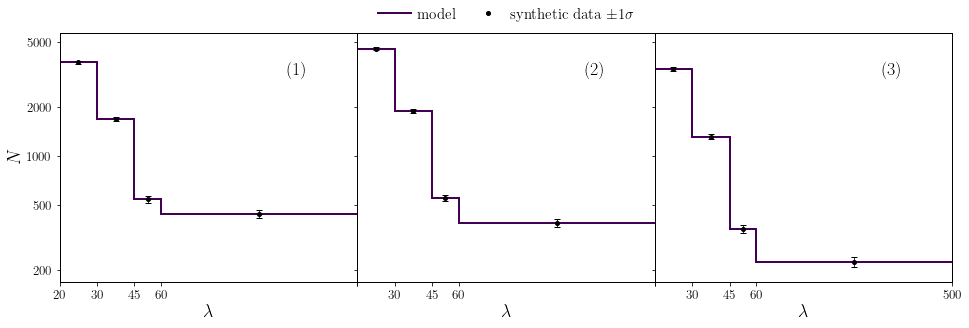

In [7]:
# counts: one panel per cluster z bin, the richness on the x axis
pdc.plot_N_cluster(N = [N_ref],
                   richness_edges = richness_edges,
                   data = (data["N"], error["N"]),
                   datalabel = r"synthetic data $\pm 1\sigma$",
                   legend = ["model"],
                   cmap = "viridis",
                   linewidth = [2.0],
                   figsize = (16, 4.5),
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

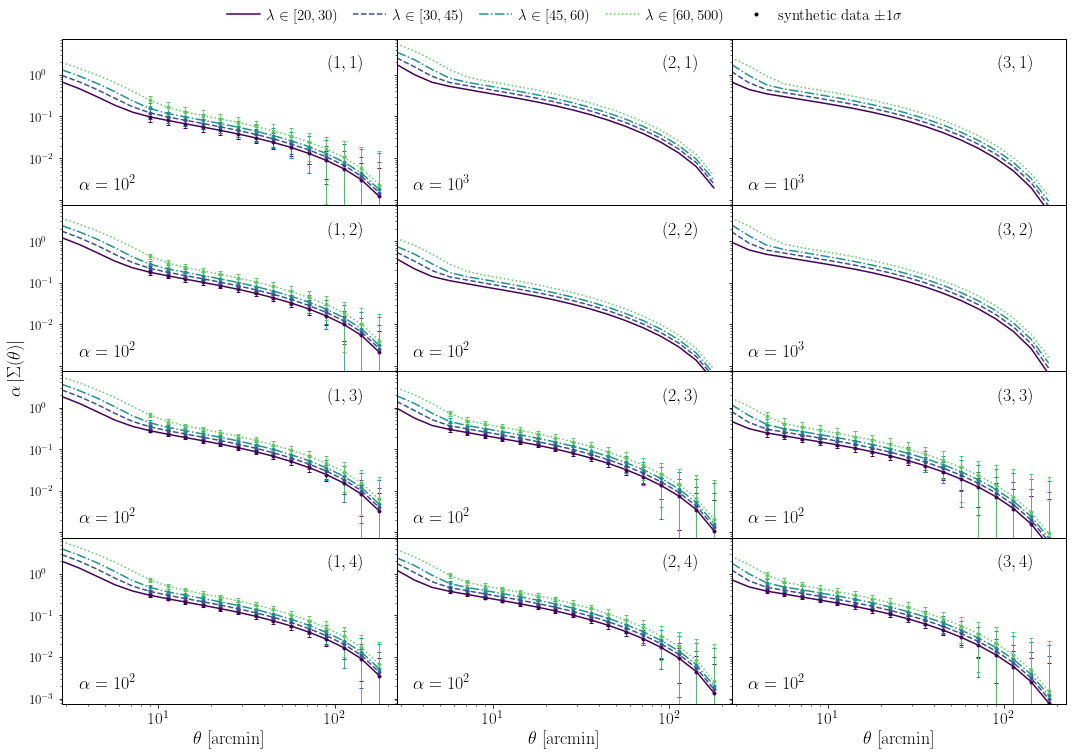

In [8]:
# cluster lensing as the data vector holds it (Sigma = Y gamma_t): columns
# = cluster z bins, rows = source bins, curves = richness bins; the points
# are the synthetic data where the scale cuts keep them
pdc.plot_sigma_cluster_tomo(theta_sigma = [sigma_ref],
                            data = (theta, data["cs"], error["cs"]),
                            datalabel = r"synthetic data $\pm 1\sigma$",
                            richnesslabel = richness_label,
                            cmap = "viridis",
                            linewidth = [1.5],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

# Let's plot how cosmological parameters affect the cluster blocks

In [9]:
param = np.linspace(0.28, 0.32, 5)
N_param, sigma_param, wcc_param, wcg_param = [], [], [], []
xi_param, gammat_param, wtheta_param = [], [], []
for x in param:
    # every block at one cosmology before moving on: the wrappers keep the
    # last CAMB run, so the sweep costs one CAMB run per parameter value
    N_param.append(nw.N_cluster(omegam=x))
    sigma_param.append(nw.sigma_cluster(omegam=x))
    wcc_param.append(nw.w_cc(selection_bias=True, omegam=x))
    wcg_param.append(nw.w_cg(selection_bias=True, omegam=x))
    xi_param.append(nw.xi(omegam=x))
    gammat_param.append(nw.gamma_t(omegam=x))
    wtheta_param.append(nw.w_theta(omegam=x))

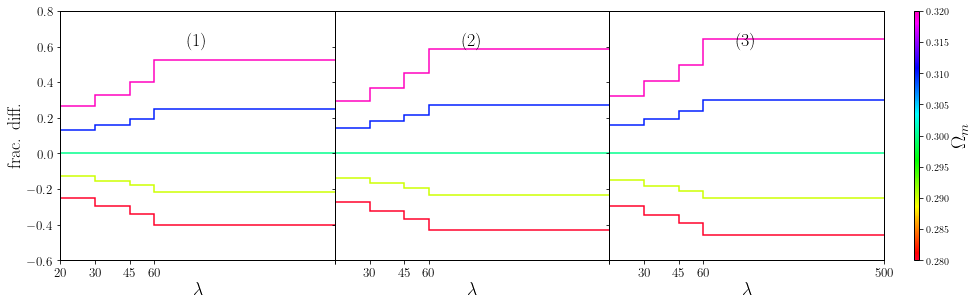

In [10]:
# Plot the ratio over the reference model
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$\Omega_m$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 1.8],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

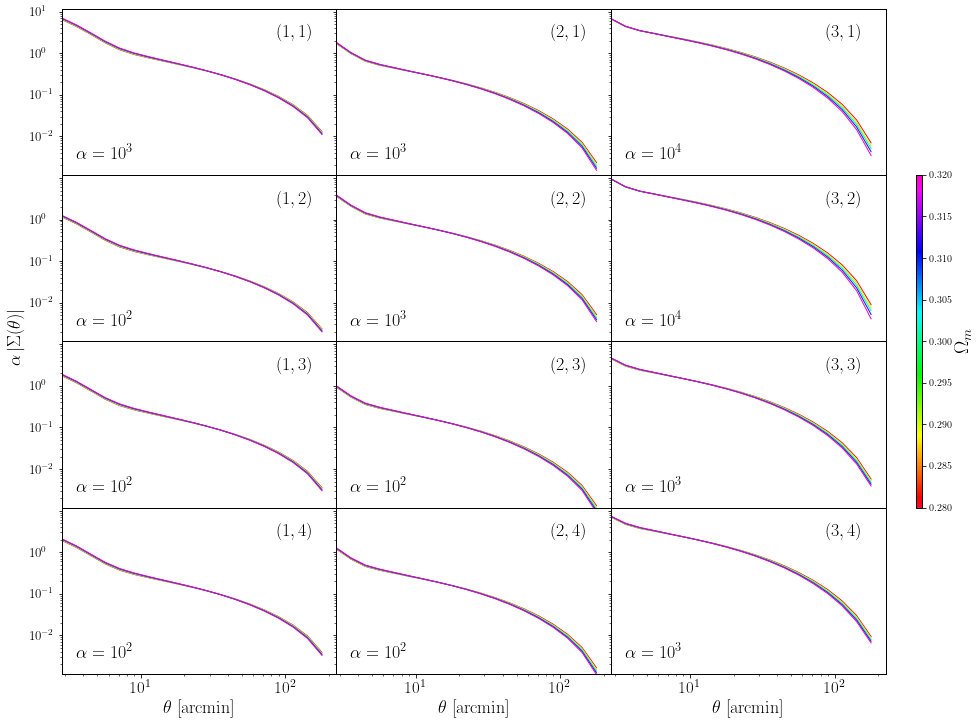

In [11]:
# Sigma itself for the lowest richness bin (richness counts from 0): one
# curve per parameter value in each panel
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            param = param,
                            colorbarlabel = r"$\Omega_m$",
                            richness = 0,
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

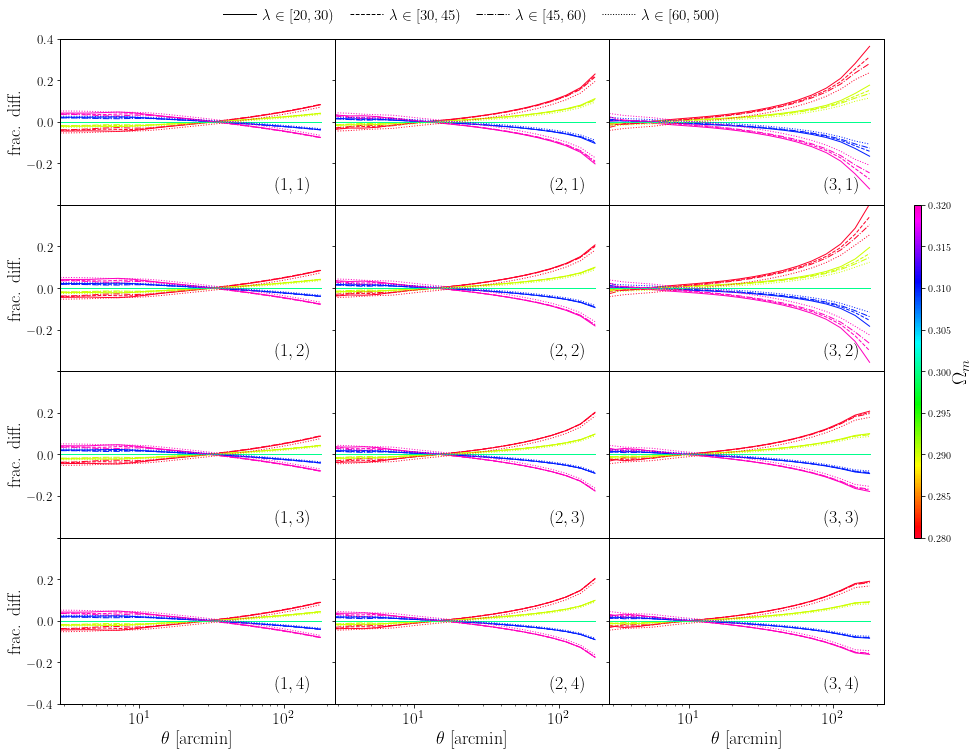

In [12]:
# ... and the ratio for every richness bin: the color is the parameter
# value, the line style the richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$\Omega_m$",
                            richnesslabel = richness_label,
                            ylim = [0.6, 1.4],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

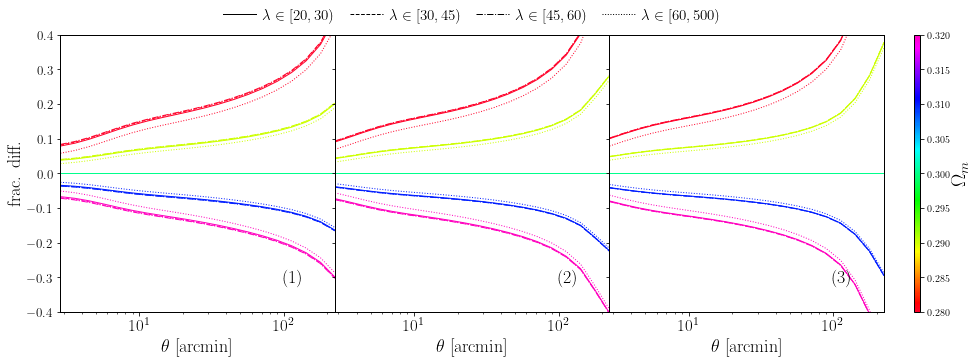

In [13]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$\Omega_m$",
                  richnesslabel = richness_label,
                  ylim = [0.6, 1.4],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

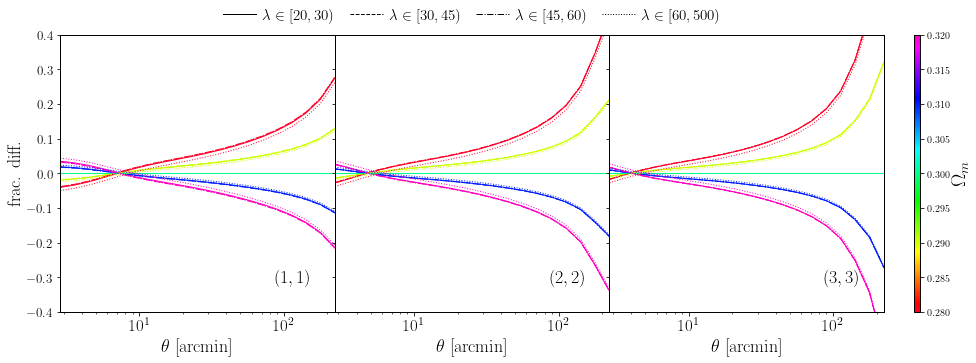

In [14]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$\Omega_m$",
                  richnesslabel = richness_label,
                  ylim = [0.6, 1.4],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

# ... and the 3x2pt blocks of 6x2pt + N (the galaxy plotting functions)

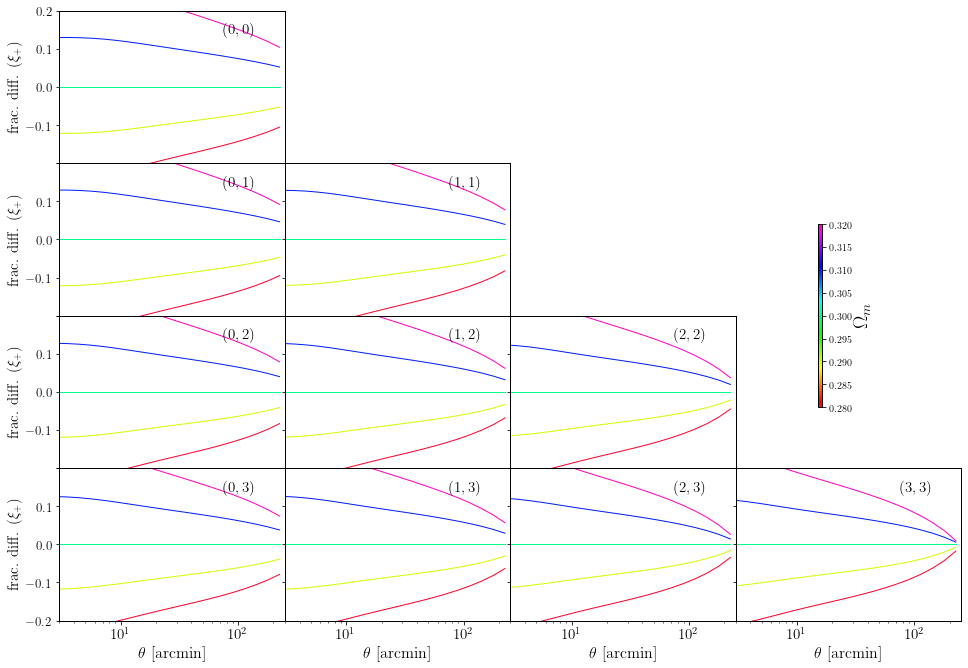

In [15]:
# cosmic shear xi_plus, as a ratio to the reference. The galaxy functions
# spread the curve colors evenly over the colormap, so with only five
# parameter values the curves sit slightly off the colorbar's colors; the
# order is the same (red = lowest value)
cnu.plot_xi(pm = 1,
            xi = xi_param,
            xi_ref = xi_ref,
            param = param,
            colorbarlabel = r"$\Omega_m$",
            ylim = [0.8, 1.2],
            yaxislabelsize = 15,
            xaxisticklabelsize = 15,
            yaxisticklabelsize = 13,
            figsize = (16, 11),
            wspace = 0.3)

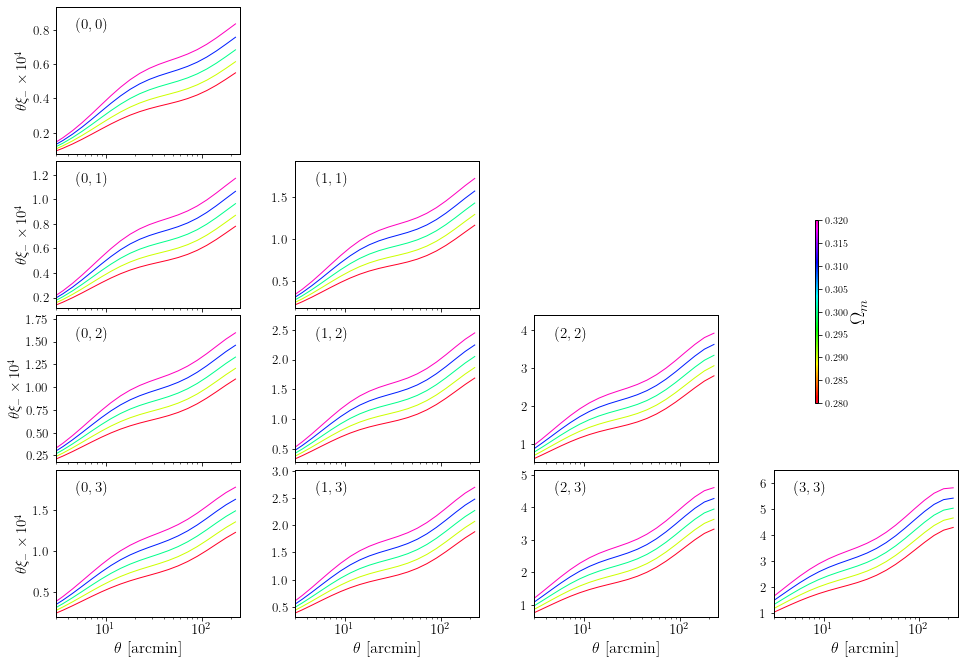

In [16]:
# xi_minus itself (theta xi_minus 10^4), one curve per parameter value
cnu.plot_xi(pm = -1,
            xi = xi_param,
            param = param,
            colorbarlabel = r"$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize = 15,
            yaxisticklabelsize = 13,
            figsize = (16, 11),
            wspace = 0.3,
            rescale = None)

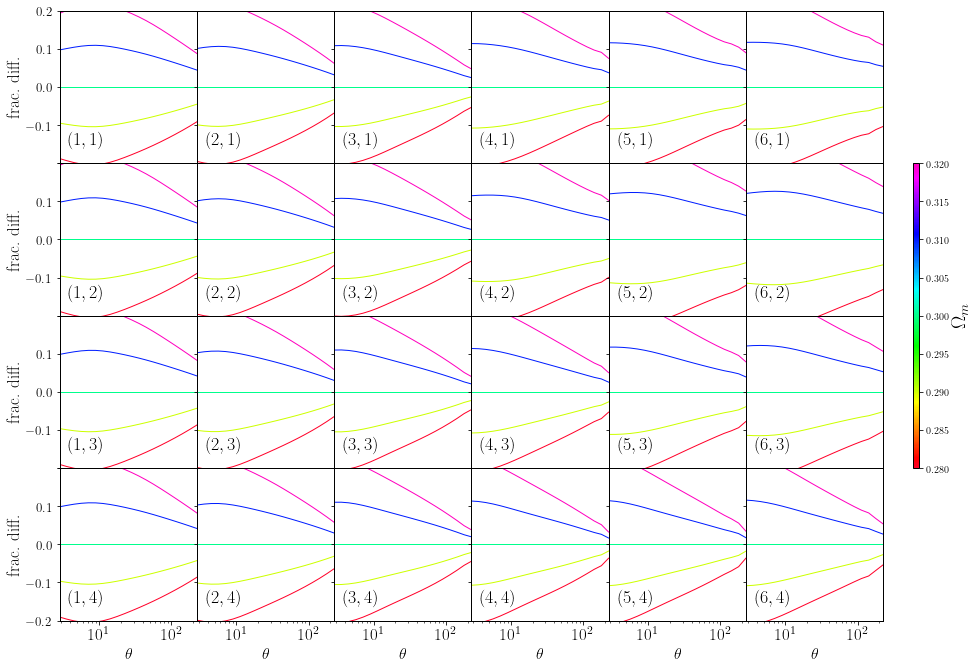

In [17]:
# galaxy-galaxy lensing: columns = lens bins, rows = source bins. The
# ratio leaves its band where gamma_t itself crosses zero (lens bins
# behind the source bin)
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_param,
                            gammat_ref = gammat_ref,
                            param = param,
                            colorbarlabel = r"$\Omega_m$",
                            bintextpos = [0.2, 0.15],
                            ylim = [0.8, 1.2],
                            figsize = (18, 11),
                            bintextsize = 18,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

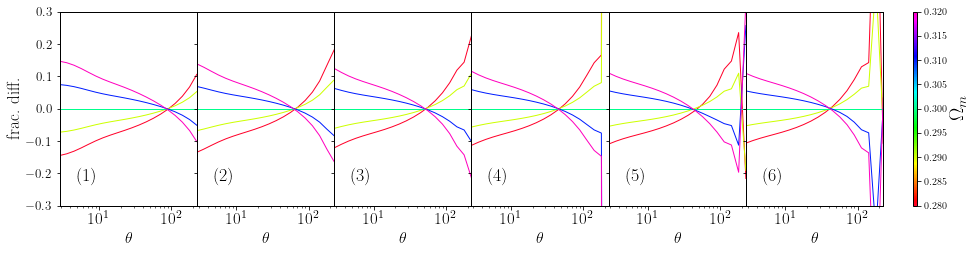

In [18]:
# galaxy clustering: one panel per lens bin
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_param,
                     theta_wtheta_ref = wtheta_ref,
                     param = param,
                     colorbarlabel = r"$\Omega_m$",
                     bintextpos = [0.2, 0.15],
                     ylim = [0.7, 1.3],
                     figsize = (18, 3.5),
                     bintextsize = 18,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 13,
                     xaxisticklabelsize = 17)

# The amplitude $A_s$

In [19]:
param = np.linspace(As_1e9 - 0.2, As_1e9 + 0.2, 5)
N_param, sigma_param, wcc_param, wcg_param = [], [], [], []
for x in param:
    N_param.append(nw.N_cluster(As_1e9=x))
    sigma_param.append(nw.sigma_cluster(As_1e9=x))
    wcc_param.append(nw.w_cc(selection_bias=True, As_1e9=x))
    wcg_param.append(nw.w_cg(selection_bias=True, As_1e9=x))

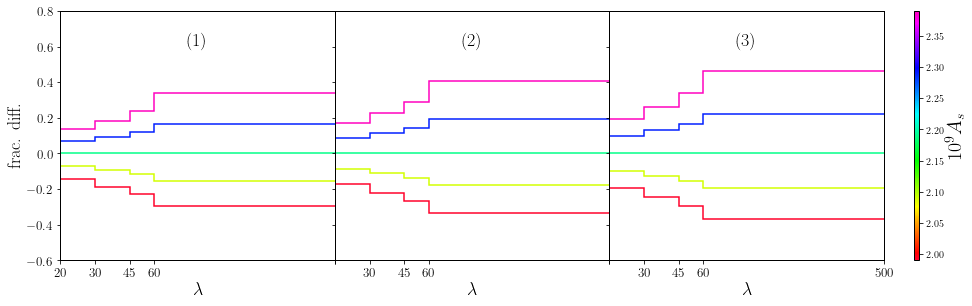

In [20]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$10^9 A_s$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 1.8],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

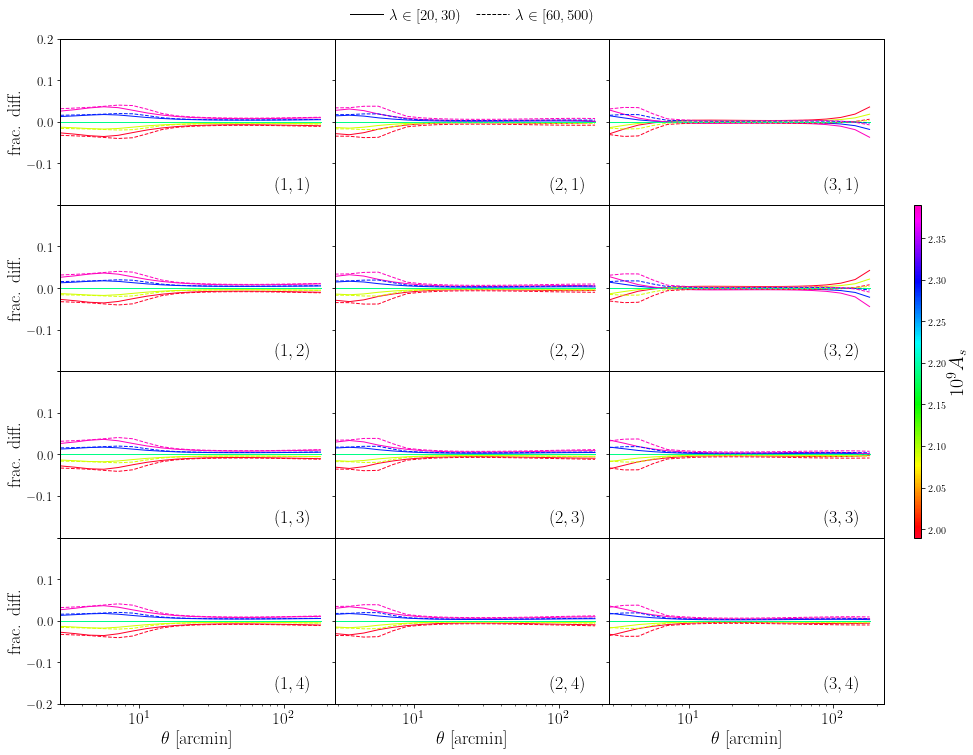

In [21]:
# the lowest and the highest richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$10^9 A_s$",
                            richnesslabel = richness_label,
                            ylim = [0.8, 1.2],
                            richness = [0, nrichness-1],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

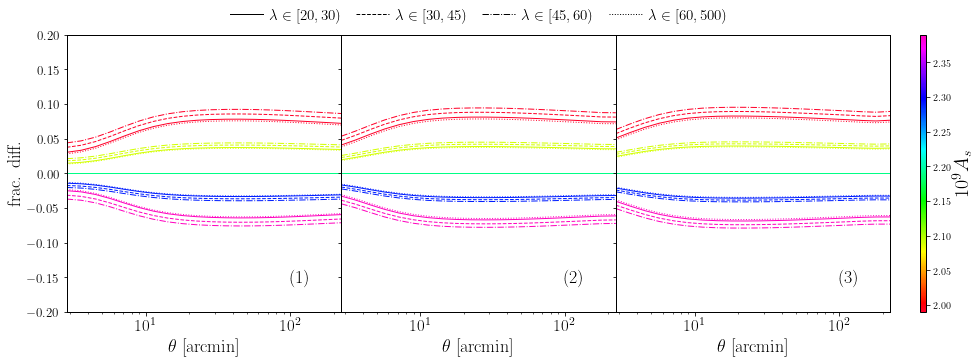

In [22]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$10^9 A_s$",
                  richnesslabel = richness_label,
                  ylim = [0.8, 1.2],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

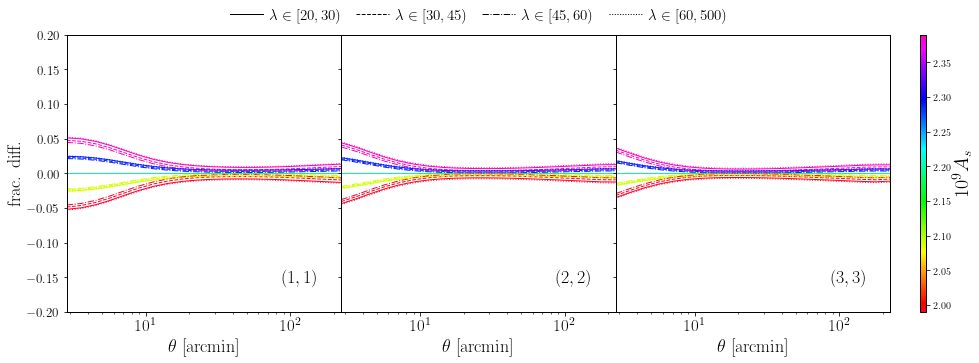

In [23]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$10^9 A_s$",
                  richnesslabel = richness_label,
                  ylim = [0.8, 1.2],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

# Let's plot how the mass-observable relation affects the cluster blocks

The mass-observable relation (eqs. 18-19 of arXiv:2503.13631) enters through `MOR = [ln lambda_0, A_lambda, sigma_int, B_lambda]`. It changes no cosmology, so these sweeps reuse the CAMB run of the fiducial point; the 3x2pt blocks do not depend on it.

In [24]:
param = np.linspace(DES_CL_LNLAMBDA0 - 0.2, DES_CL_LNLAMBDA0 + 0.2, 5)
N_param, sigma_param, wcc_param, wcg_param = [], [], [], []
for x in param:
    MOR = [x, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]
    N_param.append(nw.N_cluster(MOR=MOR))
    sigma_param.append(nw.sigma_cluster(MOR=MOR))
    wcc_param.append(nw.w_cc(selection_bias=True, MOR=MOR))
    wcg_param.append(nw.w_cg(selection_bias=True, MOR=MOR))

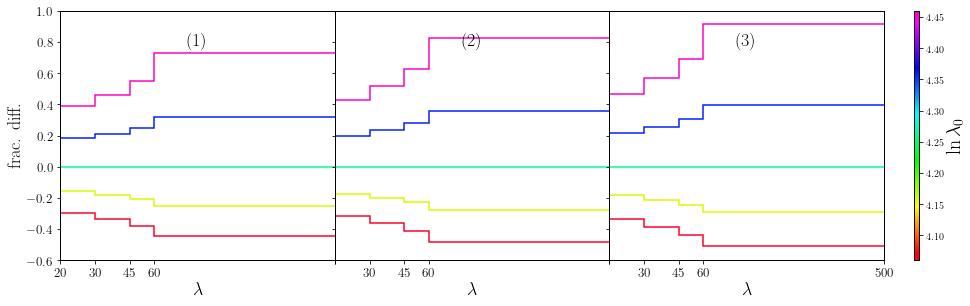

In [25]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$\ln\lambda_0$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 2.0],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

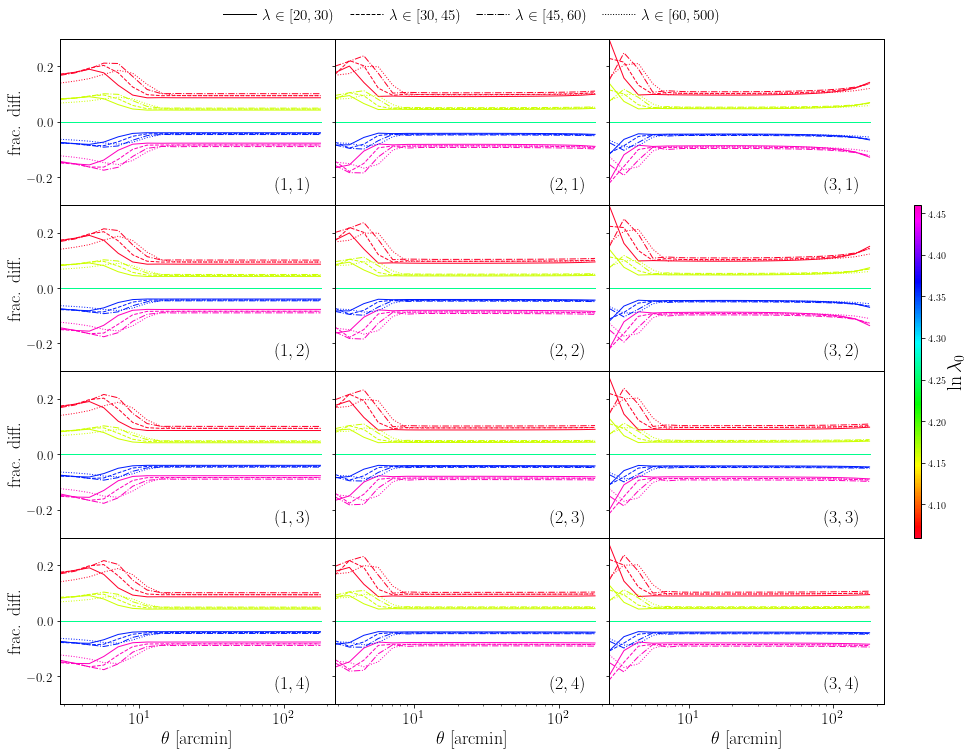

In [26]:
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$\ln\lambda_0$",
                            richnesslabel = richness_label,
                            ylim = [0.7, 1.3],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

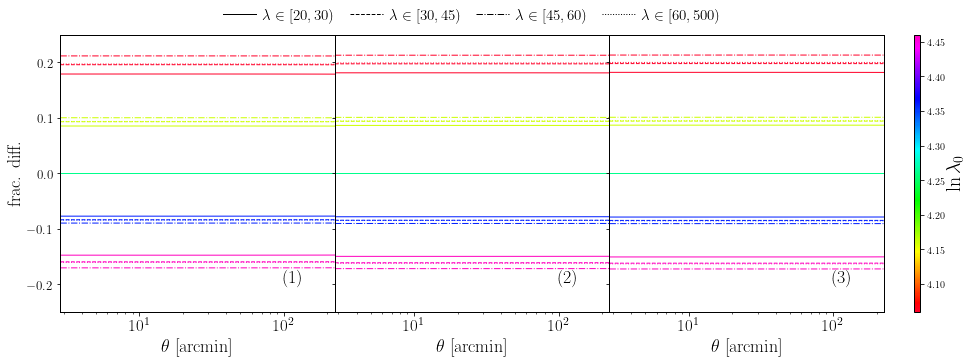

In [27]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$\ln\lambda_0$",
                  richnesslabel = richness_label,
                  ylim = [0.75, 1.25],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

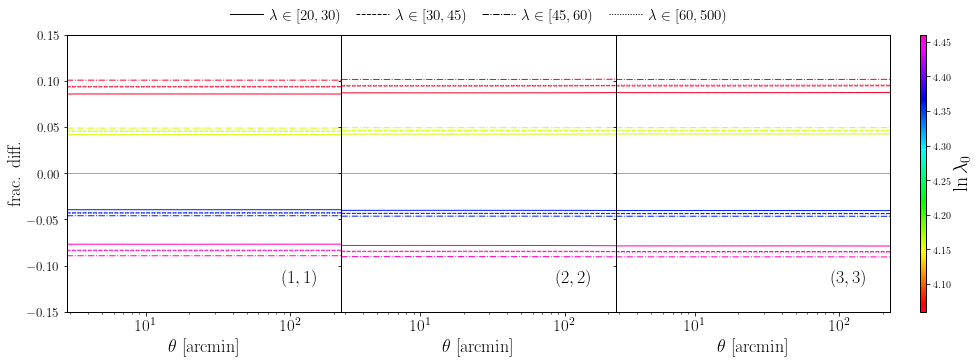

In [28]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$\ln\lambda_0$",
                  richnesslabel = richness_label,
                  ylim = [0.85, 1.15],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

In [29]:
# the intrinsic scatter of the richness at fixed mass
param = np.linspace(0.10, 0.30, 5)
N_param, sigma_param, wcc_param = [], [], []
for x in param:
    MOR = [DES_CL_LNLAMBDA0, DES_CL_A_LAMBDA, x, DES_CL_B_LAMBDA]
    N_param.append(nw.N_cluster(MOR=MOR))
    sigma_param.append(nw.sigma_cluster(MOR=MOR))
    wcc_param.append(nw.w_cc(selection_bias=True, MOR=MOR))

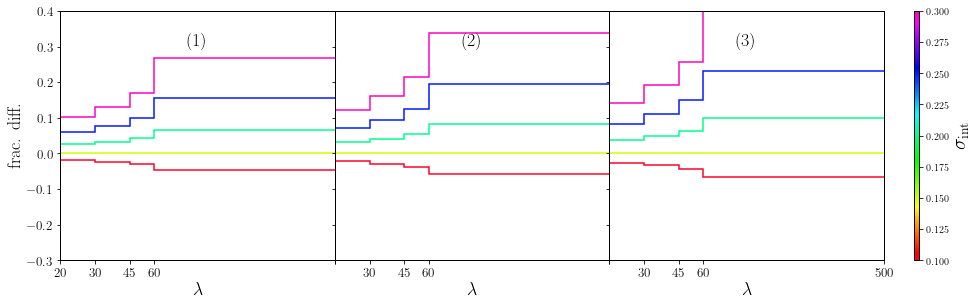

In [30]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$\sigma_{\rm int}$",
                   richness_edges = richness_edges,
                   ylim = [0.7, 1.4],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

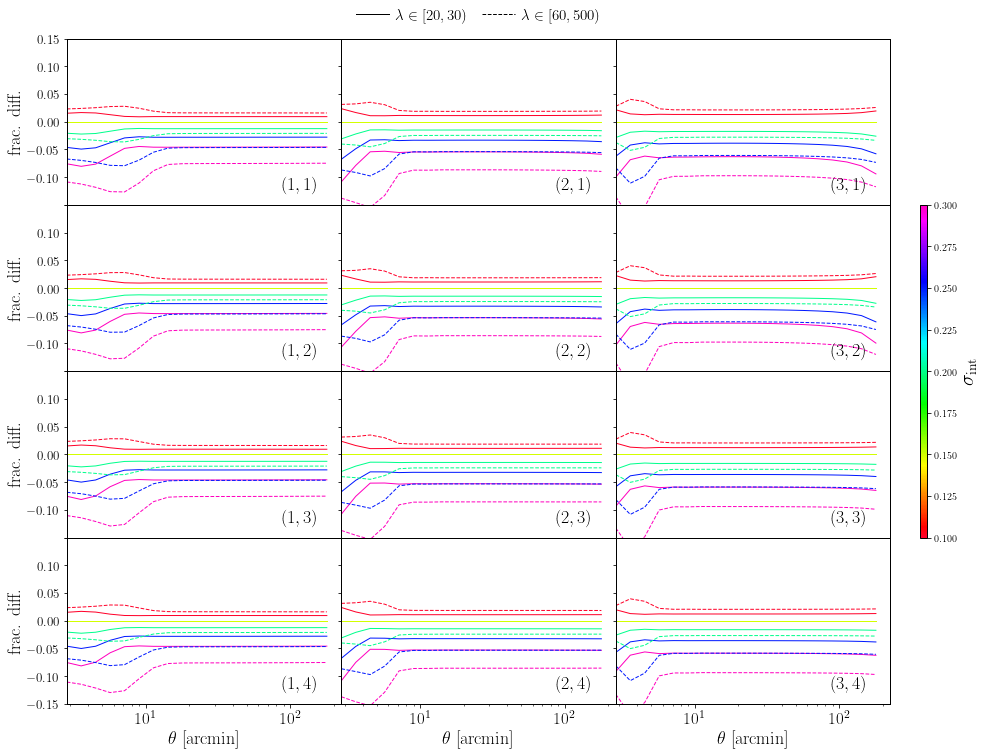

In [31]:
# the lowest and the highest richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$\sigma_{\rm int}$",
                            richnesslabel = richness_label,
                            ylim = [0.85, 1.15],
                            richness = [0, nrichness-1],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

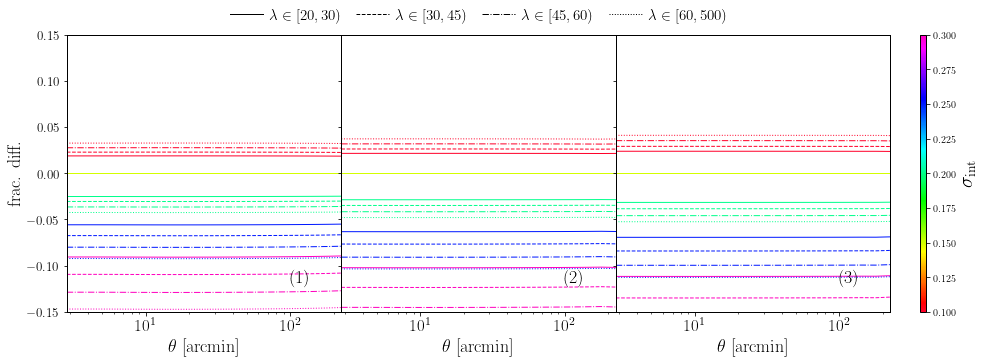

In [32]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$\sigma_{\rm int}$",
                  richnesslabel = richness_label,
                  ylim = [0.85, 1.15],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

# Let's plot how the selection bias affects the cluster blocks

The selection bias (eq. 23) multiplies $\Sigma$ and $w_{cg}$ by $B(\theta) = b_{s1} + b_{s2}\exp(-\theta\chi(\bar z)/r_0)$ and $w_{cc}$ by $B(\theta)^2$: `SEL = [b_s1, b_s2, r_0 [Mpc/h], s3]`. The counts do not depend on it.

In [33]:
param = np.linspace(0.0, 0.4, 5)
sigma_param, wcc_param, wcg_param = [], [], []
for x in param:
    SEL = [DES_CL_BS1, x, DES_CL_R0, DES_CL_BSZ]
    sigma_param.append(nw.sigma_cluster(SEL=SEL))
    wcc_param.append(nw.w_cc(selection_bias=True, SEL=SEL))
    wcg_param.append(nw.w_cg(selection_bias=True, SEL=SEL))

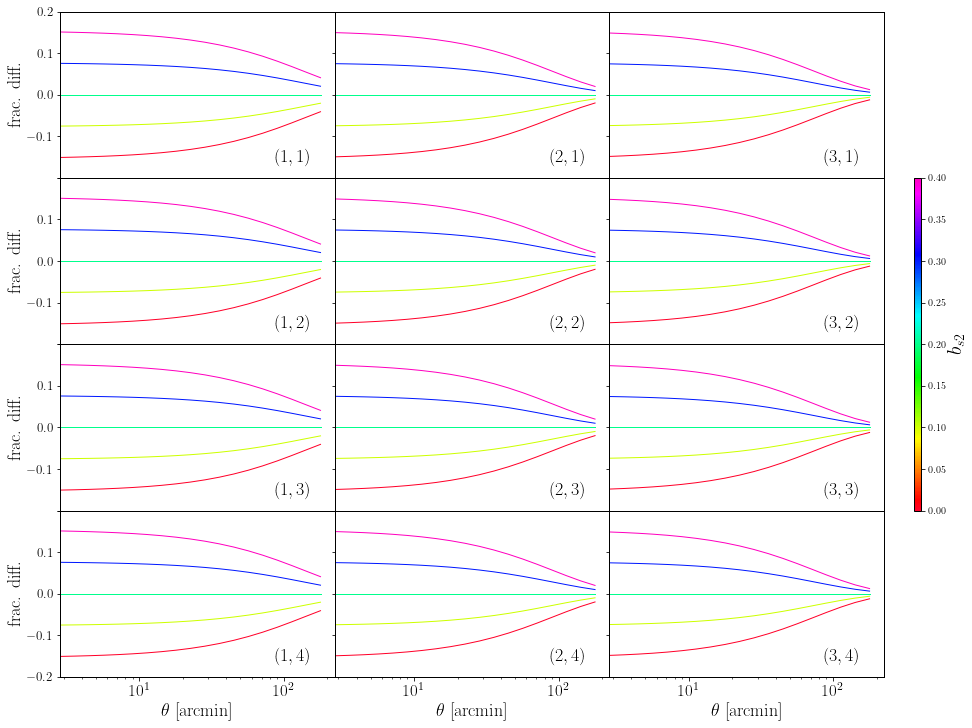

In [34]:
# the ratio is the same for every richness bin (B does not depend on
# the richness): one bin is enough
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$b_{s2}$",
                            richnesslabel = richness_label,
                            ylim = [0.8, 1.2],
                            richness = 0,
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

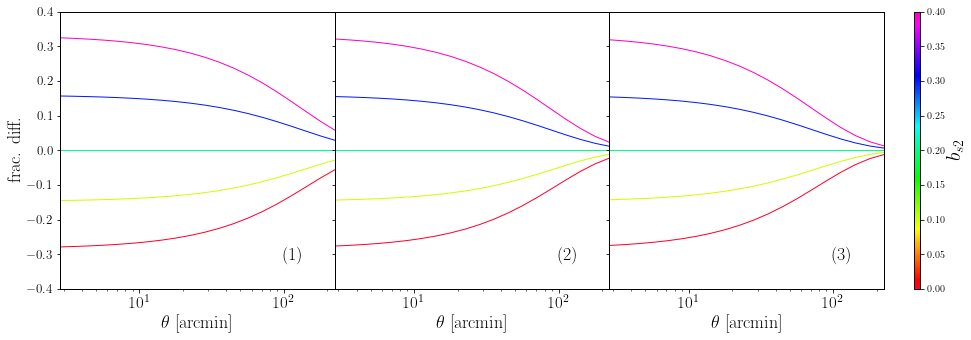

In [35]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$b_{s2}$",
                  ylim = [0.6, 1.4],
                  pairs = [(0, 0)],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

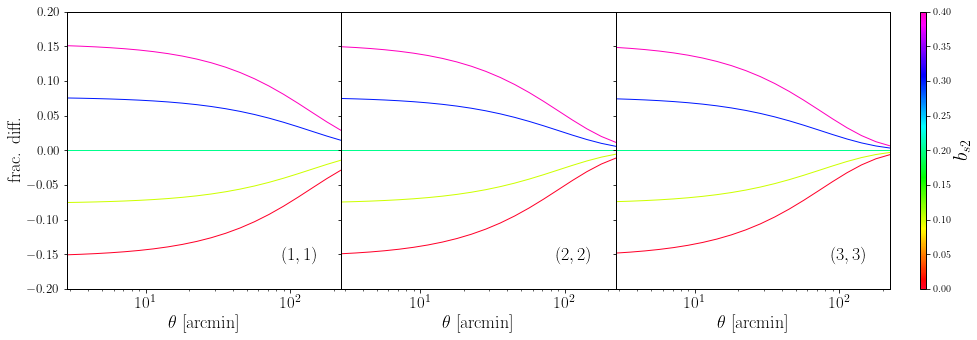

In [36]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$b_{s2}$",
                  richnesslabel = richness_label,
                  ylim = [0.8, 1.2],
                  richness = 0,
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

In [37]:
# the scale r_0 of the selection bias
param = np.linspace(10.0, 50.0, 5)
sigma_param, wcc_param = [], []
for x in param:
    SEL = [DES_CL_BS1, DES_CL_BS2, x, DES_CL_BSZ]
    sigma_param.append(nw.sigma_cluster(SEL=SEL))
    wcc_param.append(nw.w_cc(selection_bias=True, SEL=SEL))

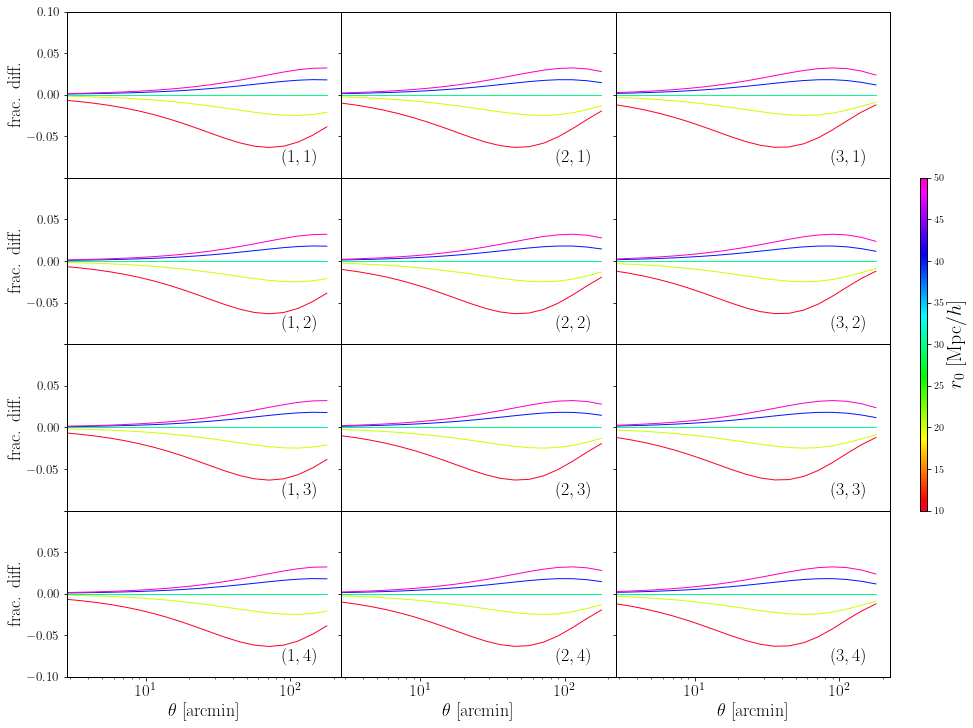

In [38]:
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$r_0\ [{\rm Mpc}/h]$",
                            richnesslabel = richness_label,
                            ylim = [0.9, 1.1],
                            richness = 0,
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

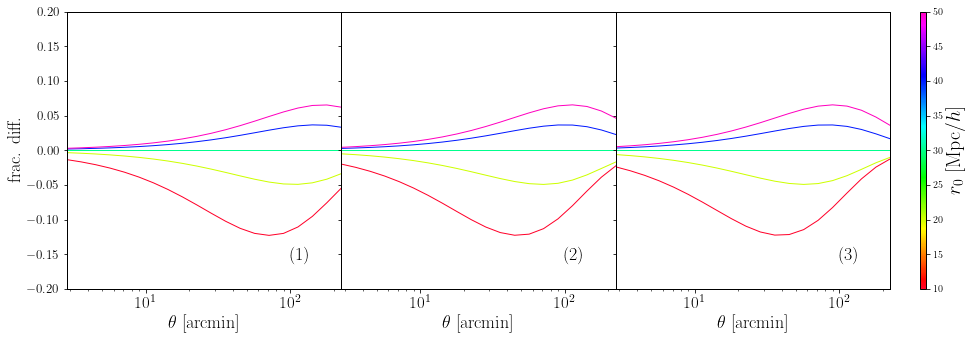

In [39]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$r_0\ [{\rm Mpc}/h]$",
                  ylim = [0.8, 1.2],
                  pairs = [(0, 0)],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

# Can we change the binning on $w_{cc}(\theta)$ and $\gamma_t(\theta)$ w/o restarting the kernel? Yes!
Why this is a nontrivial question? Because Cosmolike uses static variables to cache the bin-averaged Legendre kernels

In [40]:
nthetas = [10, 15, 20, 30]
wcc_ntheta = []
gammat_ntheta = []
for x in nthetas:
    wcc_ntheta.append(nw.w_cc(selection_bias=True, ntheta=x))
    gammat_ntheta.append(nw.gamma_t_cluster(ntheta=x))

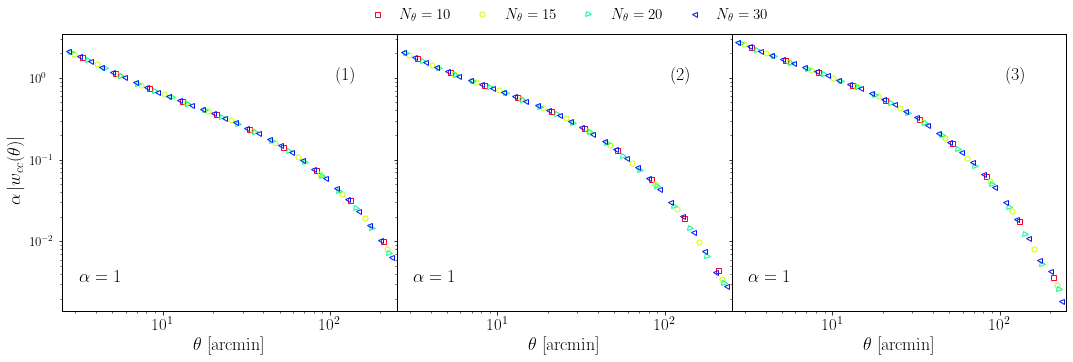

In [41]:
# one richness pair: the markers and the colors then follow the list entries
pdc.plot_wcc_tomo(theta_wcc = wcc_ntheta,
                  marker = ['s', 'o', ">", "<"],
                  markersize = 5,
                  pairs = [(0, 0)],
                  legend = [r"$N_\theta = %d$"%x for x in nthetas],
                  thetashow = [2.5, 250],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17,
                  rescale = 1,
                  ydecades = 4)

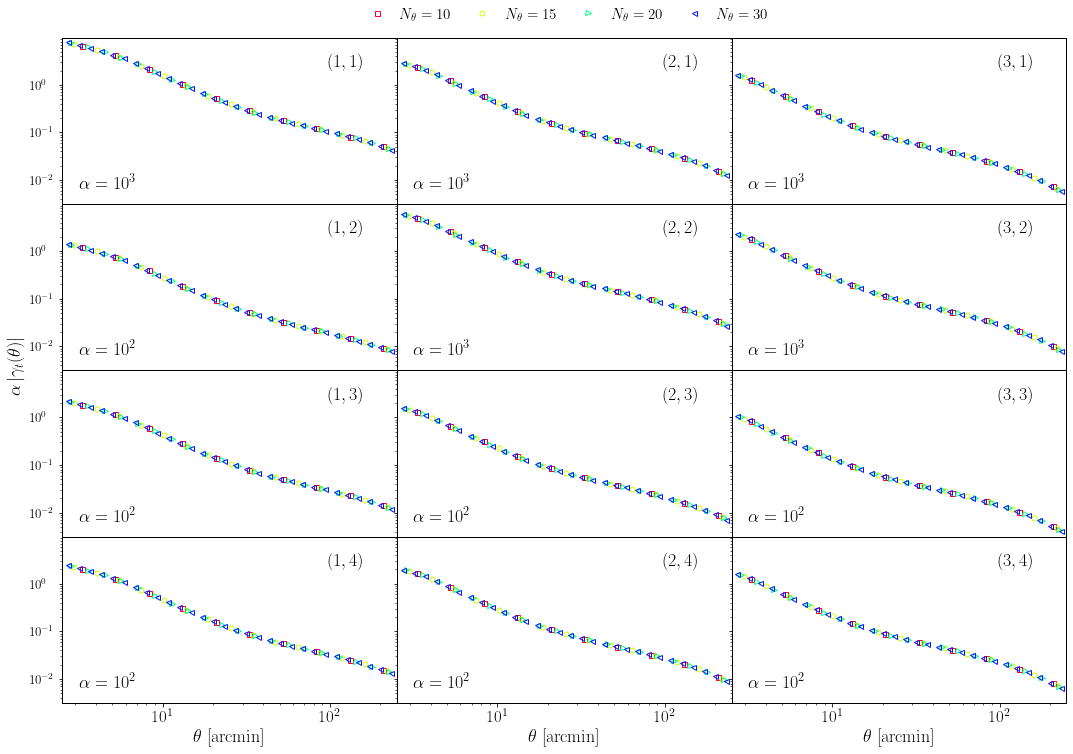

In [42]:
pdc.plot_gammat_cluster_tomo(theta_gammat = gammat_ntheta,
                             marker = ['s', 'o', ">", "<"],
                             markersize = 5,
                             richness = 0,
                             legend = [r"$N_\theta = %d$"%x for x in nthetas],
                             thetashow = [2.5, 250],
                             figsize = (18, 12),
                             bintextsize = 18,
                             yaxislabelsize = 18,
                             xaxislabelsize = 18,
                             yaxisticklabelsize = 13,
                             xaxisticklabelsize = 17,
                             rescale = 1,
                             ydecades = 4)

# Check how the Cosmolike Accuracy Boost affects the cluster blocks

In [43]:
param = np.linspace(1.0, 3.0, 5)
N_param, sigma_param, wcc_param = [], [], []
for x in param:
    # Change only Cosmolike Settings
    N_param.append(nw.N_cluster(CLAccuracyBoost=x))
    sigma_param.append(nw.sigma_cluster(CLAccuracyBoost=x))
    wcc_param.append(nw.w_cc(selection_bias=True, CLAccuracyBoost=x))

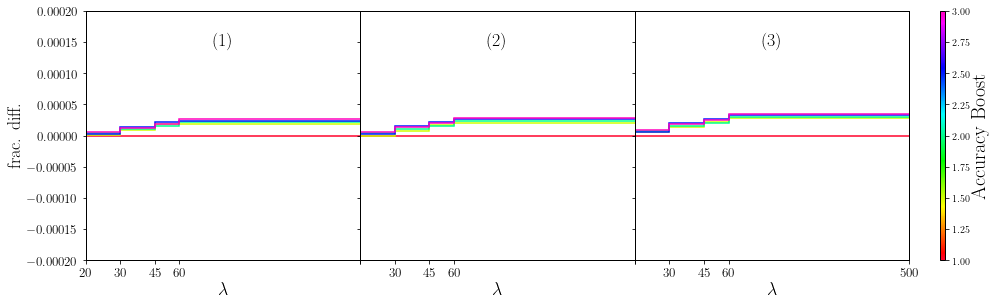

In [44]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"Accuracy Boost",
                   richness_edges = richness_edges,
                   ylim = [0.9998, 1.0002],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

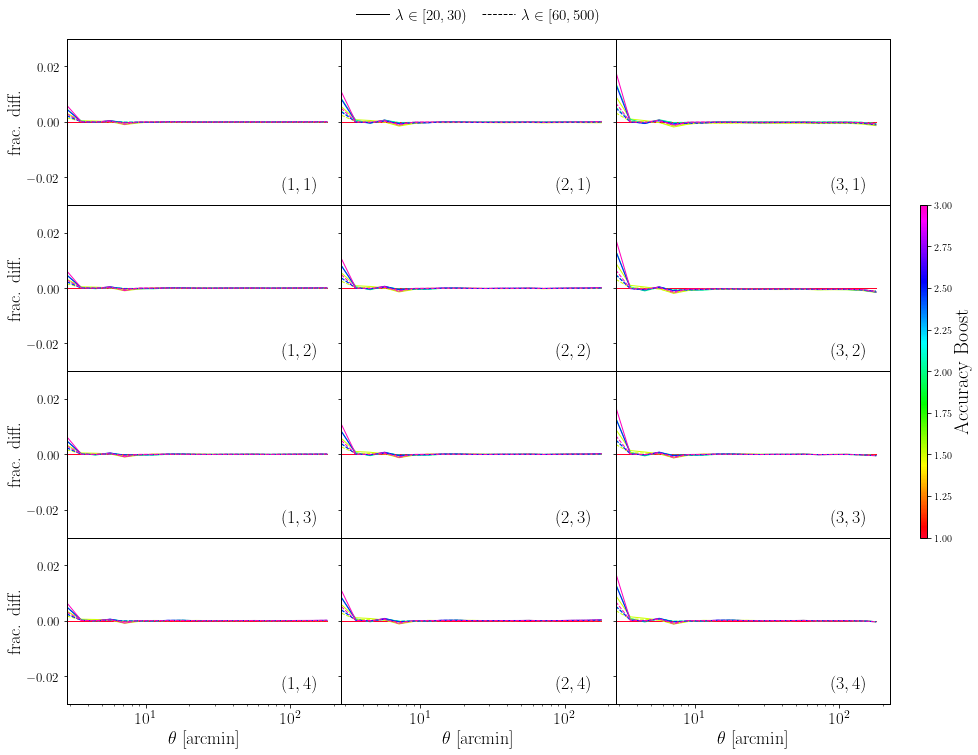

In [45]:
# the lowest and the highest richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"Accuracy Boost",
                            richnesslabel = richness_label,
                            ylim = [0.97, 1.03],
                            richness = [0, nrichness-1],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

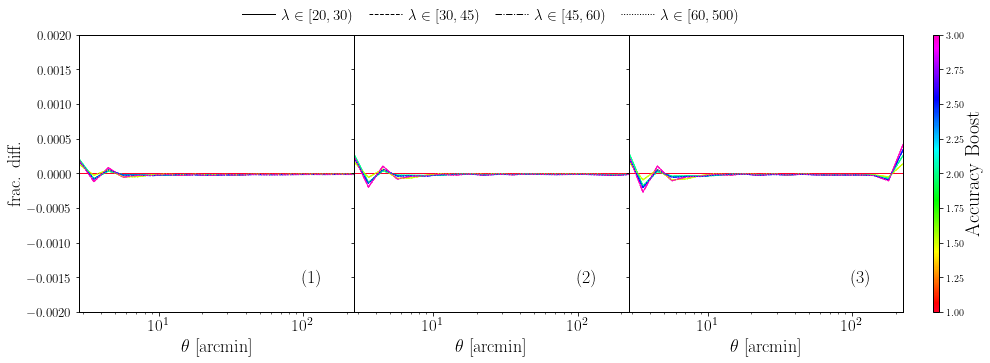

In [46]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"Accuracy Boost",
                  richnesslabel = richness_label,
                  ylim = [0.998, 1.002],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

# Let's compute $\chi^2$ against the synthetic 6x2pt + N data vector

In [47]:
# The synthetic data vector is the likelihood's model at the fiducial point
# (scripts/make_synthetic_data.py), so chi2 is small there; it is not
# exactly zero because this notebook's CAMB run is not the cobaya one.
print(r"$\chi^2$ (fiducial) = %.3e"%nw.get_chi2())
print(r"$\chi^2$ (omegam = 0.31) = %.3f"%nw.get_chi2(omegam=0.31))

$\chi^2$ (fiducial) = 1.618e-05


$\chi^2$ (omegam = 0.31) = 307.246


In [48]:
param = np.linspace(DES_CL_LNLAMBDA0 - 0.03, DES_CL_LNLAMBDA0 + 0.03, 7)
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(MOR=[x, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]))

Text(0, 0.5, '$\\chi^2$')

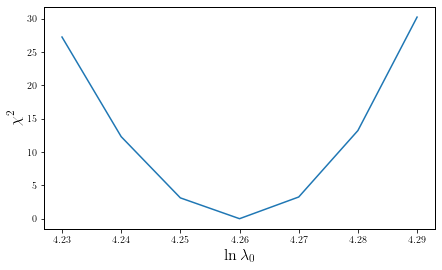

In [49]:
plt.figure(figsize=(7, 4))
plt.plot(param, chi2)
plt.xlabel(r"$\ln\lambda_0$", fontsize=16)
plt.ylabel(r"$\chi^2$", fontsize=16)